In [1]:
import h5py
import torch
import numpy as np
import os
import json

import keyrank_rs

import torch.nn as nn

from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
if os.name == "nt":
    DATAFOLDER = "C:/Data"
else:
    DATAFOLDER = "/mnt/c/Data"

val_test_hdf = h5py.File(f"{DATAFOLDER}/simpleserial-aes-fix-500-diff.hdf5")

val_test_traces = torch.Tensor(np.array(val_test_hdf['trace']))
val_test_plaintexts = torch.Tensor(np.array(val_test_hdf['data']))
val_test_keys = torch.Tensor(np.array(val_test_hdf['key']))

device = torch.device("cuda")

In [3]:
print(val_test_traces.shape)
print(val_test_plaintexts.shape)
print(val_test_keys.shape)

torch.Size([1000, 500, 5000])
torch.Size([1000, 500, 32])
torch.Size([1000, 16])


In [4]:
def metadata_best_epoch(model_name) -> int:
    with open(f"models/{model_name}/metadata.json") as f:
        metadata = json.load(f)
        val_scores = metadata["scores"][1]
        best_epoch = np.array(val_scores).argmin()
    return best_epoch.item()

def get_traces_mean_std(trace_start, trace_end):
    """Load the mean and std of the training trace set within the given interval"""
    with open(f"misc/standardization/trace{trace_start}_{trace_end}.json") as f:
        info = json.load(f)
        mean = info['training_traces_mean']
        std = info['training_traces_std']

    return mean, std

In [84]:
IMPL = "fixslice"
ARCH = "zhang"
PREDICTION_TARGET = "sbox"
TARGET_BYTE_IDX = 1
TRACE_START = 400
TRACE_END = 1500
SEED = 777

model_name = f"{IMPL}-{PREDICTION_TARGET}-byte{TARGET_BYTE_IDX}-{ARCH}-{TRACE_START}_{TRACE_END}-s{SEED}"

epoch = metadata_best_epoch(model_name)

model_path = f"models/{model_name}/epoch{epoch}.pt"
print(model_path)

model = torch.load(model_path).to()

models/fixslice-sbox-byte1-zhang-400_1500-s777/epoch32.pt


C:\Users\Ulrik\AppData\Local\Temp\ipykernel_14036\3597471133.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path).to()


In [9]:
s_box = [
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16,
]

inverted_s_box = [0] * 256

for idx, bytevalue in enumerate(s_box):
    inverted_s_box[bytevalue] = idx

In [60]:
sample = 454

traces_mean, traces_std = get_traces_mean_std(TRACE_START, TRACE_END)

traces = (val_test_traces[sample, :, TRACE_START:TRACE_END] - traces_mean) / traces_std
plaintexts_B1 = val_test_plaintexts[sample, :, :16] # first plaintext block
plaintexts_B2 = val_test_plaintexts[sample, :, 16:] # second plaintext block
key = val_test_keys[sample]

print(traces.shape)
print(plaintexts_B1.shape)
print(key.shape)

torch.Size([500, 1100])
torch.Size([500, 16])
torch.Size([16])


In [80]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_rank_dots(logits, target_a, target_b, n_ranks=32, figsize=(12, 5), dot_scale=50):
    """
    logits:   np.array of shape (n_samples, 256) — raw model output
    target_a: list of arrays/sets, one per sample — class indices for subclass A
    target_b: list of arrays/sets, one per sample — class indices for subclass B
    """

    a_ranks = []
    b_ranks = []

    classA_color="#a50bf8"
    classB_color="#378ADD"
    other_color="#888780"


    n_samples = logits.shape[0]
    hit_a = np.zeros((n_ranks, n_samples), dtype=bool)
    hit_b = np.zeros((n_ranks, n_samples), dtype=bool)

    for s in range(n_samples):
        set_a, set_b = set(target_a[s]), set(target_b[s])
        ranked = np.argsort(-logits[s])[:n_ranks]  # top n_ranks class indices, best first
        for r, cls in enumerate(ranked):
            if cls in set_a:
                hit_a[r, s] = True
                a_ranks.append(r)
            if cls in set_b:
                hit_b[r, s] = True
                b_ranks.append(r)

    print(f"Mean A rank: {np.mean(a_ranks)+1.0}")
    print(f"Mean B rank: {np.mean(b_ranks)+1.0}")


    # sort columns by rank of first hit (either subclass)
    either = hit_a | hit_b
    first_hit = np.argmax(either, axis=0)
    first_hit[~either.any(axis=0)] = n_ranks  # push empty columns right
    order = np.argsort(first_hit)
    hit_a, hit_b = hit_a[:, order], hit_b[:, order]

    fig, ax = plt.subplots(figsize=figsize)
    rows, cols = np.indices((n_ranks, n_samples))

    # non-target dots
    miss = ~(hit_a | hit_b)
    ax.scatter(cols[miss], rows[miss],
               s=dot_scale, color=other_color, alpha=0.12, linewidths=0, zorder=2)

    # subclass A — green
    ax.scatter(cols[hit_a], rows[hit_a],
               s=dot_scale, color=classA_color, alpha=0.90, linewidths=0, zorder=4)

    # subclass B — blue
    ax.scatter(cols[hit_b], rows[hit_b],
               s=dot_scale, color=classB_color, alpha=0.90, linewidths=0, zorder=4)

    # overlap (both A and B) — blend as a small teal accent on top
    overlap = hit_a & hit_b
    if overlap.any():
        ax.scatter(cols[overlap], rows[overlap],
                   s=dot_scale * 0.35, color="#1D9E75", alpha=1.0,
                   linewidths=0, zorder=5)

    ax.set_xlim(-0.5, n_samples - 0.5)
    ax.set_ylim(n_ranks - 0.5, -0.5)
    ax.set_xlabel("Sample", labelpad=8)
    ax.set_ylabel("Rank", labelpad=8)
    ax.set_xticks(np.linspace(0, n_samples - 1, min(8, n_samples), dtype=int))
    ax.set_xticklabels(np.linspace(1, n_samples, min(8, n_samples), dtype=int))
    ax.set_yticks(np.arange(0, n_ranks, max(1, n_ranks // 8)))
    ax.set_yticklabels(np.arange(1, n_ranks + 1, max(1, n_ranks // 8)))
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor("#f8f8f8")
    fig.patch.set_facecolor("white")

    handles = [
        mpatches.Patch(color=classA_color, label="subclass A"),
        mpatches.Patch(color=classB_color, label="subclass B"),
        mpatches.Patch(color=other_color, alpha=0.4, label="other"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=9)

    plt.tight_layout()
    return fig

In [96]:
sbox1_indices = []
sbox2_indices = []
key_indices = []

for block1, block2 in zip(plaintexts_B1, plaintexts_B2):

    block1_sbox = block1.map_(key, lambda x,y: s_box[int(x) ^ int(y)])
    block2_sbox = block2.map_(key, lambda x,y: s_box[int(x) ^ int(y)])

    sbox1_indices.append(block1_sbox.tolist()[1:2])
    sbox2_indices.append(block2_sbox.tolist()[1:2])
    key_indices.append(key.long().tolist()[1:2])

In [86]:
plaintexts_B1.shape

torch.Size([500, 16])

Mean A rank: 129.166
Mean B rank: 123.226


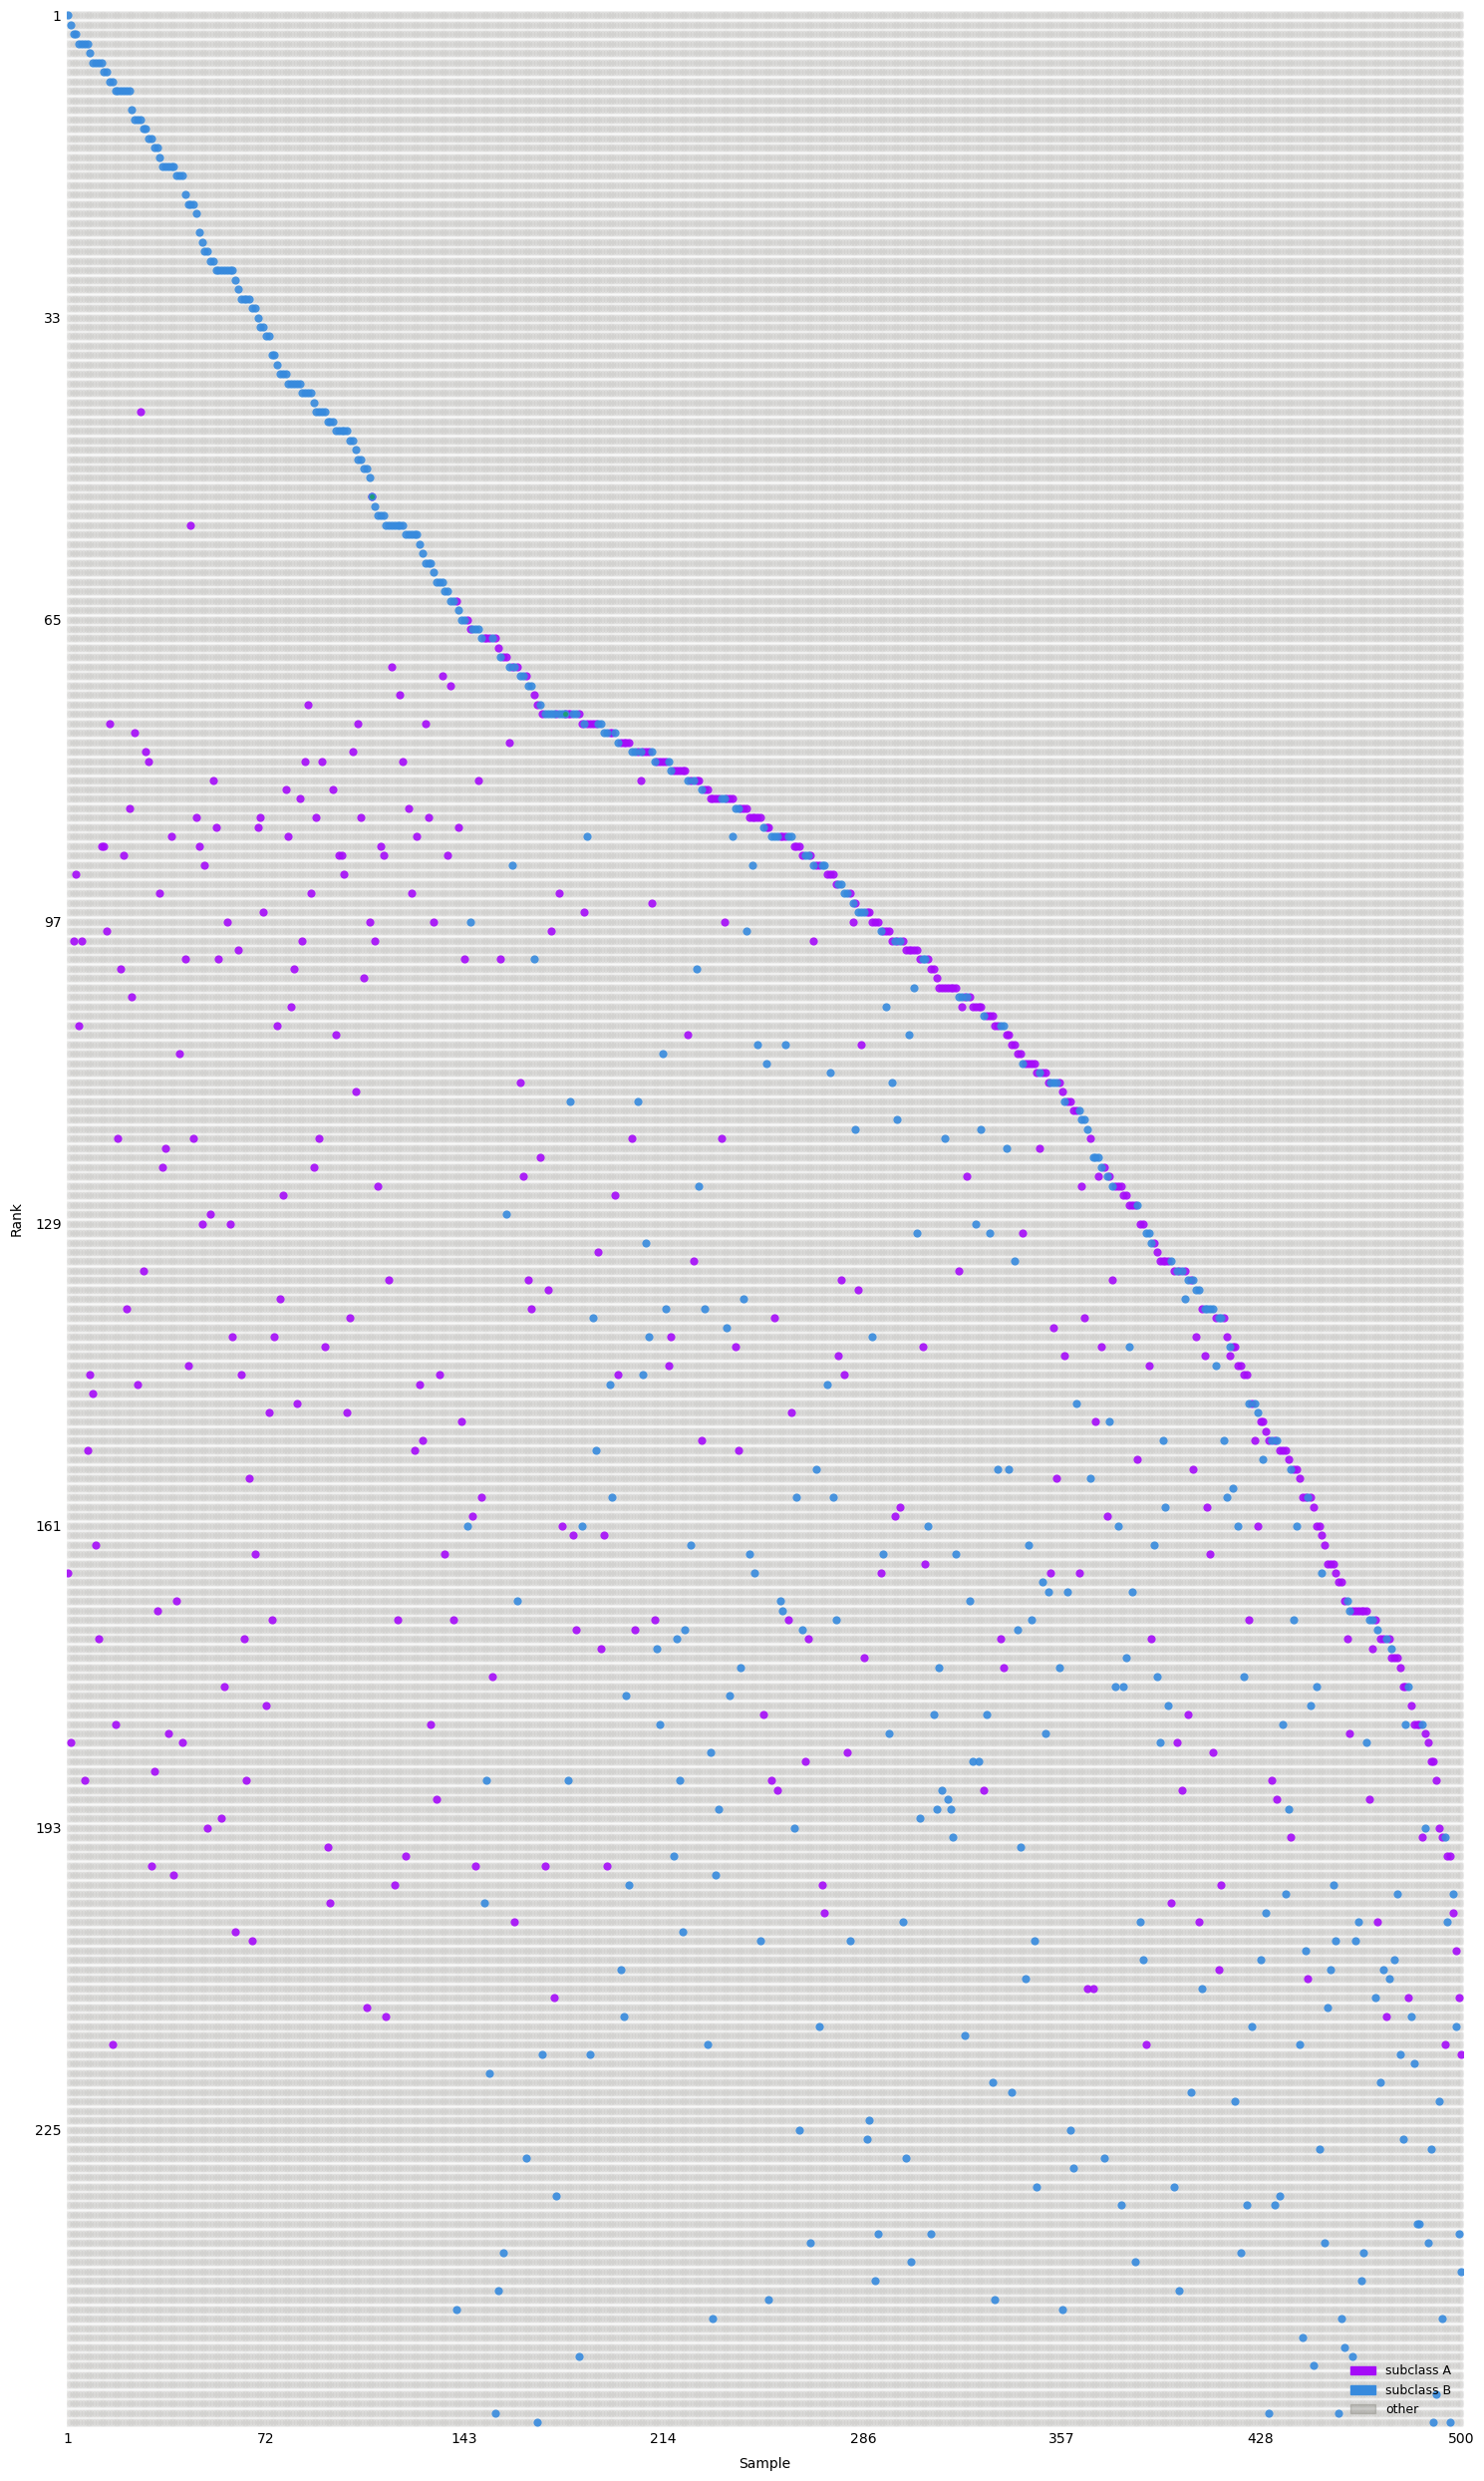

In [100]:
import keyrank_rs

import torch.nn as nn

softmax_log = nn.LogSoftmax(dim=1)

sbox_scores = model(traces.to(device))
numpy_scores = sbox_scores.detach().cpu().numpy()

numpy_keyscores = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintexts_B1[:,1].long().tolist(), numpy_scores)

keyscores_tensor = torch.Tensor(numpy_keyscores)

keyscores_tensor = softmax_log(keyscores_tensor).cumsum(axis=0)

numpy_keyscores = keyscores_tensor.numpy()

plot_rank_dots(
    numpy_keyscores,
    target_a=key_indices,
    target_b=sbox2_indices,
    n_ranks=256,
    figsize=(15, 25),
    dot_scale=35
    )

plt.show()

In [8]:
"""Compute mean traces needed for full key recovery across N different keys, using both plaintext blocks"""

log_softmax = nn.LogSoftmax(dim=1)

traces_needed = []

for sample_idx in tqdm(range(0,500)):

    traces_ = (val_test_traces[sample_idx, :, TRACE_START:TRACE_END] - traces_mean) / traces_std
    plaintexts_B1_ = val_test_plaintexts[sample_idx, :, :16] # first plaintext block
    plaintexts_B2_ = val_test_plaintexts[sample_idx, :, 16:] # second plaintext block
    true_key_ = val_test_keys[sample_idx].long()

    sbox_scores = model(traces_.to(device))
    numpy_sbox_scores = sbox_scores.detach().cpu().numpy()

    full_guesses = torch.zeros(500,16)

    for subkey in range(16):
        plaintext_B1_bytes = plaintexts_B1_[:, subkey]
        plaintext_B1_bytes = plaintext_B1_bytes.long().detach().cpu().numpy().squeeze()

        plaintext_B2_bytes = plaintexts_B2_[:, subkey]
        plaintext_B2_bytes = plaintext_B2_bytes.long().detach().cpu().numpy().squeeze()

        numpy_keyscores1 = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintext_B1_bytes, numpy_sbox_scores)
        numpy_keyscores2 = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintext_B2_bytes, numpy_sbox_scores)

        x = torch.Tensor(numpy_keyscores1 + numpy_keyscores2)
        #x = torch.Tensor(numpy_keyscores2)
        x = log_softmax(x)
        x = x.cumsum(dim=0)
        guesses = x.argmax(dim=1)
        full_guesses[:, subkey] = guesses

    success = (full_guesses.long() == true_key_).all(dim=1)
    n_traces = success.nonzero()[0].item() + 1
    traces_needed.append(n_traces)



mean_traces_needed = np.mean(traces_needed)

mean_traces_needed

100%|██████████| 500/500 [00:35<00:00, 14.22it/s]


29.044